# Hierarchical Mixture of Experts for CIFAR-10
This notebook demonstrates a Hierarchical Mixture of Experts (MoE) Architecture where multiple CNN experts specialize in different classes, and gating networks route inputs to the appropriate experts.

## 1. Import Dependencies

In [1]:
import os
import numpy as np
import tensorflow as tf
from utils.data_loader import load_and_preprocess_cifar10, to_one_hot
from models.moe_model import HierarchicalMoE
from utils.visualization import plot_confusion_matrix

In [2]:
!pip install numpy tensorflow scikit-learn matplotlib seaborn


^C


   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 1.0/351.2 MB 5.5 MB/s eta 0:01:04
   ---------------------------------------- 2.1/351.2 MB 5.0 MB/s eta 0:01:10
   ---------------------------------------- 2.6/351.2 MB 4.8 MB/s eta 0:01:14
   ---------------------------------------- 3.4/351.2 MB 4.2 MB/s eta 0:01:24
   ---------------------------------------- 4.2/351.2 MB 4.2 MB/s eta 0:01:24
    --------------------------------------- 5.0/351.2 MB 3.9 MB/s eta 0:01:29
    --------------------------------------- 5.8/351.2 MB 3.9 MB/s eta 0:01:28
    --------------------------------------- 6.6/351.2 MB 3.9 MB/s eta 0:01:29
    --------------------------------------- 7.6/351.2 MB 3.9 MB/s eta 0:01:28
    --------------------------------------- 8.4/351.2 MB 4.0 MB/s eta 0:01:27
   - -------------------------------------- 9.4/351.2 MB 4.0 MB/s eta 0:01:26
   - -------------------------------------- 10.0/351.2 MB 3.9 MB/s eta 


[notice] A new release of pip is available: 25.0 -> 26.0.1
[notice] To update, run: C:\Users\admin\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


## 2. Load Data

In [2]:
(x_train, y_train), (x_val, y_val), (x_test, y_test) = load_and_preprocess_cifar10()
print('Data Loaded and Preprocessed.')
print('Test set shapes:', x_test.shape, y_test.shape)

Data Loaded and Preprocessed.
Test set shapes: (10000, 32, 32, 3) (10000, 1)


## 3. Train Models
To run this project, you first need to train the models via command line or uncomment the below cell to run training sequentially.

```bash
python experts/train_experts.py --epochs 20
python gating/first_level.py --epochs 10
python gating/second_level.py --epochs 10
```

In [3]:
# !python experts/train_experts.py --epochs 10
# !python gating/first_level.py --epochs 5
# !python gating/second_level.py --epochs 5

## 4. Load Models and Initialize MoE

In [4]:
try:
    moe = HierarchicalMoE(models_dir='saved_models')
except Exception as e:
    print('Could not load models. Please make sure to train them first!')
    print(e)

Loading experts...
Loading gating networks...
All models loaded successfully.


## 5. Evaluate MoE on Test Set

In [5]:
y_test_oh = to_one_hot(y_test)
moe_accuracy = moe.evaluate(x_test, y_test_oh, batch_size=64)
print(f'Hierarchical MoE Test Accuracy: {moe_accuracy:.4f}')

Hierarchical MoE Test Accuracy: 0.8218


## 6. Evaluate Base Expert on Test Set (For Comparison)

In [6]:
base_expert = tf.keras.models.load_model('saved_models/base_expert_final.keras')
base_preds = base_expert.predict(x_test, verbose=0)
base_acc = tf.keras.metrics.CategoricalAccuracy()(y_test_oh, base_preds).numpy()
print(f'Standard CNN (Base Expert) Test Accuracy: {base_acc:.4f}')

Standard CNN (Base Expert) Test Accuracy: 0.8147


## 7. Analysis & Visualizations

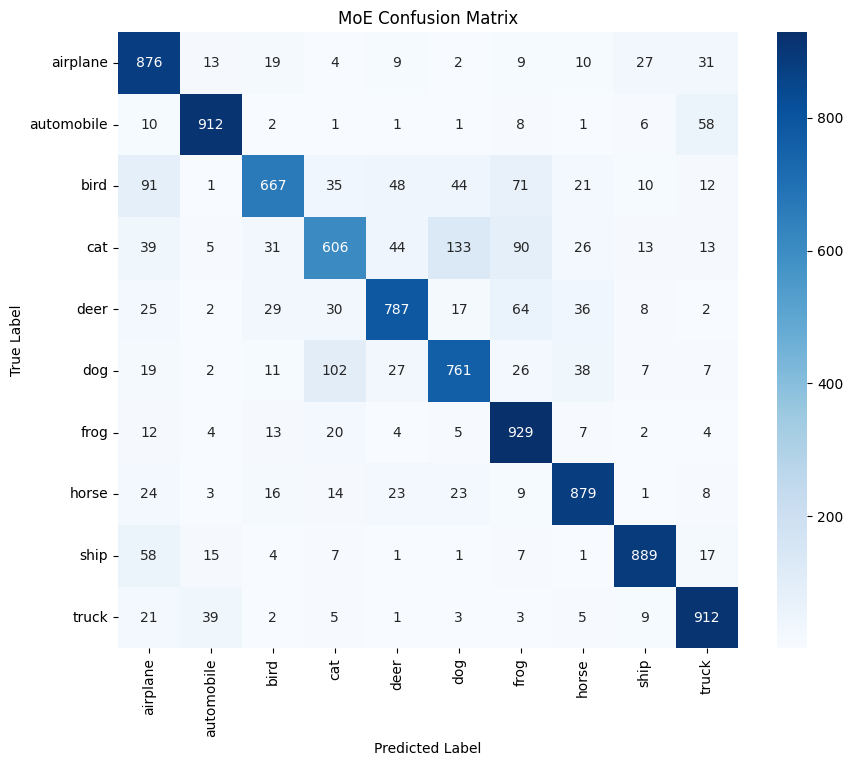

In [7]:
moe_preds = moe.predict(x_test, batch_size=128, verbose=0)
moe_pred_labels = np.argmax(moe_preds, axis=1)
true_labels = y_test.flatten()

classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
plot_confusion_matrix(true_labels, moe_pred_labels, classes, title='MoE Confusion Matrix')

### Sample Routing Decisions

In [8]:
sample_images = x_test[:5]
sample_labels = true_labels[:5]
routing_info = moe.get_routing_info(sample_images)

for i in range(5):
    print(f'--- Image {i+1} | True Label: {classes[sample_labels[i]]} ---')
    print(f'P(Natural Route): {routing_info["prob_natural"][i][0]:.4f}')
    print(f'P(Artificial Route): {routing_info["prob_artificial"][i][0]:.4f}')
    print(f'If Routed Artificial -> Weights (Base: {routing_info["weight_art_branch"][i][0]:.4f}, Spec: {routing_info["weight_art_branch"][i][1]:.4f})')
    print(f'If Routed Natural -> Weights (Base: {routing_info["weight_nat_branch"][i][0]:.4f}, Spec: {routing_info["weight_nat_branch"][i][1]:.4f})')
    print('-'*50)


--- Image 1 | True Label: cat ---
P(Natural Route): 0.9694
P(Artificial Route): 0.0306
If Routed Artificial -> Weights (Base: 0.3699, Spec: 0.6301)
If Routed Natural -> Weights (Base: 0.4577, Spec: 0.5423)
--------------------------------------------------
--- Image 2 | True Label: ship ---
P(Natural Route): 0.0000
P(Artificial Route): 1.0000
If Routed Artificial -> Weights (Base: 0.4364, Spec: 0.5636)
If Routed Natural -> Weights (Base: 0.0885, Spec: 0.9115)
--------------------------------------------------
--- Image 3 | True Label: ship ---
P(Natural Route): 0.0094
P(Artificial Route): 0.9906
If Routed Artificial -> Weights (Base: 0.5014, Spec: 0.4986)
If Routed Natural -> Weights (Base: 0.3016, Spec: 0.6984)
--------------------------------------------------
--- Image 4 | True Label: airplane ---
P(Natural Route): 0.0428
P(Artificial Route): 0.9572
If Routed Artificial -> Weights (Base: 0.4898, Spec: 0.5102)
If Routed Natural -> Weights (Base: 0.1745, Spec: 0.8255)
----------------